# <span style='color: darkblue'>Predicting Heart Disease</span>

## <span style='color: blue'>Introduction</span>

Cardiovascular diseases (CVDs) are estimate by the World Health Organisation (WHO) to cause 17.9 million deaths every year.

This project is to develop a model to predict the likelihood of a new patient having heart disease is the future.

A dataset of anonamised [data](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) from multiple hospitals on several patients has been collected that includes information such as personal and medical data as well as indicating whether the patient has previously had heart disease or not.

*<span style='color: green'>Import libraries to be used in this project...<span>*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

*<span style='color: green'>Load the dataset in to a DataFrame...<span>*

In [2]:
heart_disease_df = pd.read_csv('heart_disease_prediction.csv')

*<span style='color: green'>Inspect the first few rows of the DataFrame...<span>*

In [3]:
heart_disease_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


*<span style='color: green'>Assess the size of the DataFrame...<span>*

In [4]:
observation_count = heart_disease_df.shape[0]
features_count = heart_disease_df.shape[1] - 1
target_count = 1

print('The dataset contains {:,} rows (observations) and {} columns ({} features, {} target variable).'
      .format(observation_count, features_count + target_count, features_count, target_count))

The dataset contains 918 rows (observations) and 12 columns (11 features, 1 target variable).


## <span style='color: blue'>EDA: Descriptive Statistics</span>

The dataset, as per the source documentation, has the following features:

1. `Age`: age of the patient (years)
1. `Sex`: sex of the patient (M: Male, F: Female)
1. `ChestPainType`: chest pain type (TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic)
1. `RestingBP`: resting blood pressure (mm Hg)
1. `Cholesterol`: serum cholesterol (mm/dl)
1. `FastingBS`: fasting blood sugar (1: if FastingBS > 120 mg/dl, 0: otherwise)
1. `RestingECG`: resting electrocardiogram results (Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria)
1. `MaxHR`: maximum heart rate achieved (Numeric value between 60 and 202)
1. `ExerciseAngina`: exercise-induced angina (Y: Yes, N: No)
1. `Oldpeak`: oldpeak = ST (Numeric value measured in depression)
1. `ST_Slope`: the slope of the peak exercise ST segment (Up: upsloping, Flat: flat, Down: downsloping)
1. `HeartDisease`: output class (1: heart disease, 0: Normal)

*<span style='color: green'>Display the descriptive statistics for the DataFrame...<span>*

In [5]:
heart_disease_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Running `describe()` on the DataFrame displays summary statistics for the numerical columns.

Note that both `FastingBS` and `HeartDisease` are actually categorical variables.

It can be seen that there are no missing values in any of these columns but there might be in other columns in the DataFrame.

Some observations include:

* The average `Age` of patients was approximately 54 years of age.
* `RestingBP` and `Cholesterol` both have minimum values of zero, potentially indicating missing data.
* The summary statistics for `Cholesterol` indicate that there is a possibility of outliers on the high side and that this feature could be left-skewed.

## <span style='color: blue'>EDA: Visualisations</span>

*<span style='color: green'>Calculate the number of missing values in all columns...</span>*

In [6]:
heart_disease_df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Notwithstanding what was mentioned previously, there are no missing values in the DataFrame.

*<span style='color: green'>Investigate the distributions of the categorical columns...</span>*

In [7]:
categoricals = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope", "HeartDisease"]

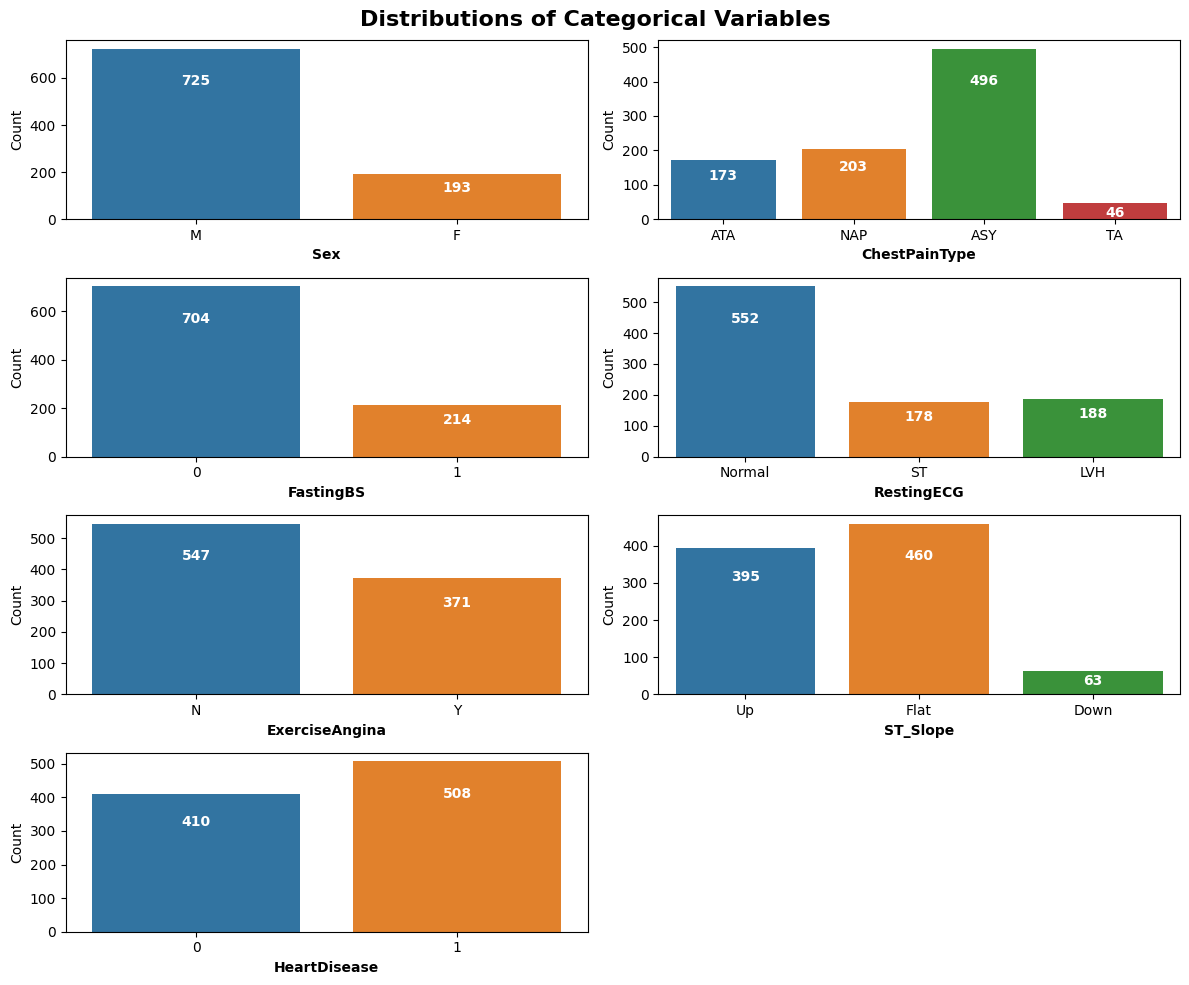

In [8]:
plt.style.use('default')
cols = 2
rows = -(-len(categoricals) // cols) # Double negative in this formula forces rounding up rather than down.
fig, axes = plt.subplots(rows,
                         cols,
                         figsize=(12, 2.5 * rows))
axes = axes.flatten()
for i, col in enumerate(categoricals):
    ax = axes[i]
    plot = sns.countplot(data=heart_disease_df,
                         x=col,
                         ax=ax,
                         hue=col,
                         legend=False)
    for p in plot.patches:
        height = int(p.get_height())
        plot.annotate('{}'.format(height),
                      (p.get_x() + p.get_width() / 2, height * 0.85),
                      ha='center',
                      va='top',
                      fontsize=10,
                      fontweight='bold',
                      color='white')
    ax.set_xlabel(col, fontweight='bold')
    ax.set_ylabel('Count')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distributions of Categorical Variables',
             fontsize=16,
             fontweight='bold')
plt.tight_layout()
plt.show()

The above plots highlight the following:
* There were far more male patients than female (725 male, 193 female) indicating potential problems for predictions for female patients
* Most had a Chest Pain Type as asymptomatic (ASY) (496 out of 918)
* Most had `FastingBS` > 120 mg/dl (704 v 214)
* There were slightly more patients with heart disease

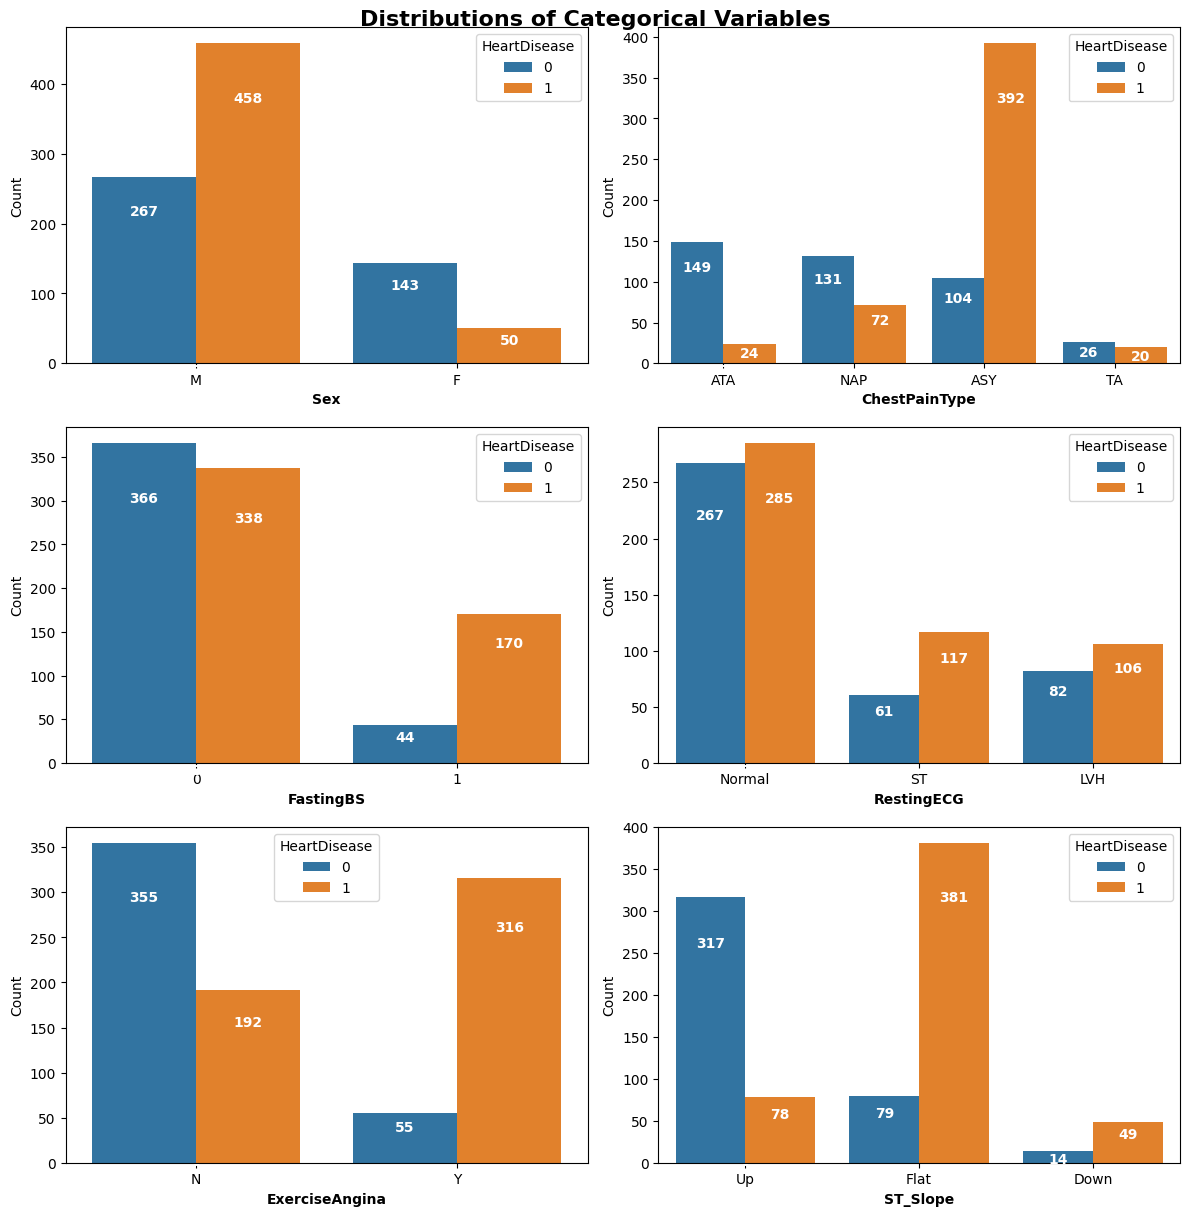

In [9]:
fig, axes = plt.subplots(rows,
                         cols,
                         figsize=(12, 4 * rows))
axes = axes.flatten()
for i, col in enumerate(categoricals[:-1]):
    ax = axes[i]
    plot = sns.countplot(data=heart_disease_df,
                         x=col,
                         ax=ax,
                         hue='HeartDisease',
                         legend=True)
    for p in plot.patches:
        height = int(p.get_height())
        plot.annotate('{}'.format(height),
                      (p.get_x() + p.get_width() / 2, height * 0.85),
                      ha='center',
                      va='top',
                      fontsize=10,
                      fontweight='bold',
                      color='white')
    ax.set_xlabel(col, fontweight='bold')
    ax.set_ylabel('Count')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distributions of Categorical Variables',
             fontsize=16,
             fontweight='bold')
plt.tight_layout()
plt.show()

Splitting the category columns by `HeartDisease` reveals things such as:
* There were more occurences of `HeartDisease` for male patients than not and fewer female patients with `HeartDisease` than with
* For `ChestPainType`, the vast majoriy with heart disease were asymptomatic
* `ExerciseAngina` was higher for those with heart disease
* `ST_Slope` was mainly flat for those with heart disease and mainly 'up' for those without

## <span style='color: blue'>Data Cleaning</span>

`RestingBP` and `Cholesterol` columns both contained zeros that don't make sense.

In [10]:
heart_disease_df[heart_disease_df['RestingBP'] == 0].shape[0]

1

In [11]:
heart_disease_df[heart_disease_df['Cholesterol'] == 0].shape[0]

172

There is only 1 row where `RestingBP` is zero so that row can be discarded.

The number of rows with zero value for `Cholesterol` is significant so those values shall be replaced by the median `Cholesterol` value with respect to `HeartDisease`.

*<span style='color: green'>Replace zeros in Cholestoral with median values based on `HeartDisease`...</span>*

In [12]:
hd_yes_query = (heart_disease_df['Cholesterol'] != 0) & (heart_disease_df['HeartDisease'] == 1)
hd_no_query = (heart_disease_df['Cholesterol'] != 0) & (heart_disease_df['HeartDisease'] == 0)

hd_yes_cholesterol_median = heart_disease_df[hd_yes_query]['Cholesterol'].median()
hd_no_cholesterol_median = heart_disease_df[hd_no_query]['Cholesterol'].median()

def update_cholesterol(row):
    if row['Cholesterol'] == 0 and row['HeartDisease'] == 1:
        return hd_yes_cholesterol_median
    elif row['Cholesterol'] == 0 and row['HeartDisease'] == 0:
        return hd_no_cholesterol_median
    return row['Cholesterol']

heart_disease_df['Cholesterol'] = heart_disease_df.apply(update_cholesterol, axis=1)

In [13]:
heart_disease_df['Cholesterol'].describe()

count    918.000000
mean     244.575163
std       53.356165
min       85.000000
25%      214.000000
50%      246.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

*<span style='color: green'>Remove the row with zero value `RestingBP`...</span>*

In [14]:
heart_disease_df = heart_disease_df[heart_disease_df['RestingBP'] != 0].copy()

## <span style='color: blue'>Feature Selection</span>

To decide which features to use in the model, further analysis will be carried out to establish correlation to the target variable.

*<span style='color: green'>Convert categorical variables to dummy variables...</span>*

In [15]:
heart_disease_df = pd.get_dummies(heart_disease_df, drop_first=True)

*<span style='color: green'>Calculate and inspect correlations with the target variable...</span>*

In [16]:
correlations = abs(heart_disease_df.corr())['HeartDisease'].sort_values(ascending=False).iloc[1:]
correlations

ST_Slope_Up          0.621843
ST_Slope_Flat        0.553700
ExerciseAngina_Y     0.495490
Oldpeak              0.403638
ChestPainType_ATA    0.401680
MaxHR                0.401410
Sex_M                0.305118
Age                  0.282012
FastingBS            0.267994
ChestPainType_NAP    0.215311
RestingBP            0.117990
Cholesterol          0.103803
RestingECG_ST        0.103067
RestingECG_Normal    0.092452
ChestPainType_TA     0.054591
Name: HeartDisease, dtype: float64

Given the previous analysis and the results on correlation, features with a correlation coefficient above 0.25 will be used in the model.

In [17]:
features = list(correlations[correlations > 0.25].index)

## <span style='color: blue'>Building a Classifier I<span>

First, train a K Nearest Neighbours Classifier on each of the selected features individually.

*<span style='color: green'>Split the dataset in to training and validation sets...</span>*

In [18]:
X = heart_disease_df.drop('HeartDisease', axis=1)
y = heart_disease_df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6)

*<span style='color: green'>Model each of the selected features in turn and measure the resulting accuracy...<span>*

In [19]:
for feature in features:
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train[[feature]], y_train)
    accuracy = knn.score(X_test[[feature]], y_test)
    print(f'Feature "{feature}" KNN classifier with k=3 resulted in an accuracy score of {accuracy:.2f}%')

Feature "ST_Slope_Up" KNN classifier with k=3 resulted in an accuracy score of 0.85%
Feature "ST_Slope_Flat" KNN classifier with k=3 resulted in an accuracy score of 0.82%
Feature "ExerciseAngina_Y" KNN classifier with k=3 resulted in an accuracy score of 0.79%
Feature "Oldpeak" KNN classifier with k=3 resulted in an accuracy score of 0.54%
Feature "ChestPainType_ATA" KNN classifier with k=3 resulted in an accuracy score of 0.41%
Feature "MaxHR" KNN classifier with k=3 resulted in an accuracy score of 0.58%
Feature "Sex_M" KNN classifier with k=3 resulted in an accuracy score of 0.41%
Feature "Age" KNN classifier with k=3 resulted in an accuracy score of 0.58%
Feature "FastingBS" KNN classifier with k=3 resulted in an accuracy score of 0.55%


The accuracy scores from using individual features in the model generally reflected the strength of the correlation to the target variable.

## <span style='color: blue'>Building a Classifier II<span>

Now build a Classifier using all of the selected features (after normalisation of those features).

*<span style='color: green'>Normalise selected features in training and test datasets...</span>*

In [20]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[features])
X_test_scaled = scaler.transform(X_test[features])

*<span style='color: green'>Train a new model with the selected normalised features...</span>*

In [21]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
accuracy = knn.score(X_test_scaled, y_test)
print(f'The accuracy of the new model is {accuracy:.2f}%')

The accuracy of the new model is 0.85%


The accuracy of the new model was no better or worse than the top performaing individual model (`ST_Slope_Up`).

## <span style='color: blue'>Hyperperameter Tuning</span>

To test tuning `n_neighbors` and the `metric` parameters, use `scikit-learn`'s `GridSearchCV`.

*<span style='color: green'>Create a dictionary to store the parameters and values to be tested...</span>*

In [22]:
params = {
    'n_neighbors': range(1, 20),
    'metric': ['minkowski', 'manhattan']
}

In [23]:
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, param_grid=params, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'metric': ['minkowski', 'manhattan'],
                         'n_neighbors': range(1, 20)},
             scoring='accuracy')

In [24]:
print(f'The best accuracy score from the Grid Search was {knn_grid.best_score_ * 100:.2f}%')
print(f'The best parameters were {knn_grid.best_params_}')

The best accuracy score from the Grid Search was 84.58%
The best parameters were {'metric': 'manhattan', 'n_neighbors': 16}


The resulting accuracy score was very similar to the previous model but should now be tested on the test dataset.

## <span style='color: blue'>Model Evaluation on Test Set</span>

*<span style='color: green'>Evaluate the test data set using the best parameters from the Grid Search...</span>*

In [25]:
predictions = knn_grid.best_estimator_.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print(f'The accuracy score of the model on the test dataset was {accuracy * 100:.2f}%')

The accuracy score of the model on the test dataset was 86.41%


The resulting accuracy score of approximately 87% is fairly good.

There are things to be concerned about, however, in the dataset that could affect the model and its predictions, such as the distribution of certain features.

It is clear that `Sex` is heavily skewed in favour of male patients.

Some further analysis is required to analyse the impact of this and other potential bias.